In [1]:
# 1. interpolation w.r.t. n instead of e
# 2. added semi-analytical calculation

import tmm
import tmm_helper as tmm_h

from numpy import pi, inf
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
%matplotlib inline
#%matplotlib qt
#plt.rcParams['figure.figsize'] = [3,2]


# Load external plotting functions
from plot_functions import plot_setup, plot, legend

# Load plotting colors
import colors # make available colors from schmid_colors.py 

# Image file settings
fmt = '.png' # image format (use png for PowerPoint, pdf and eps for publications)
dpi = 300 # image resolution, density of pixels per inch (use at least 300)
fig_dir = 'C:\\Users\\kl89\\MS Window Project\\Figures\\'

degree = pi/180

In [2]:
# Lorentzian dielectric function for spatial KK stack
def eps(x, a, gam, nb):
    return nb**2 - a * gam / (x + 1j*gam)

In [3]:
def generate_n_and_d_old(gam, a, nb, plot_flag):

    del_n   = np.sqrt(a)/100                # Max e-step size in discrete Lorentzian approximation
    del_x   = 5*gam                # Max x-step size in discrete Lorentzian approximation
    dx      = gam/100               # Step size in 'continuous' Lorentzian
    xmin    = -gam * 200           # Limits of Lorentzian
    xmax    = - xmin

    nx      = 1 + int(np.floor((xmax - xmin) / dx))
    xx      = np.linspace(xmin, xmax, nx)
    ee      = eps(xx,a,gam,nb)                    # Smooth Lorentzian curve
    nk      = np.sqrt(ee)

    xq      = [xx[0]]                               
    nq      = [nb]
    count = 0
    for k in range(0,nx):
        if abs((nk[k]) - (nq[count])) > del_n or abs((xx[k]) - (xq[count])) > del_x:
            xq.append(xx[k])
            nq.append(nk[k])
            count = count + 1

    xq = np.append(xq,xmax)
    nq = np.append(nq,nb)
    midpoints = (xq[:-1] + xq[1:]) / 2
    d_list = np.diff(midpoints)
    n_list  = nq[1:-1]

    #midpoints = np.insert(midpoints,0,xq[0]); midpoints = np.append(midpoints,xq[-1])
    #d_list = np.insert(d_list,0,inf); d_list = np.append(d_list,inf)          # Append super- & sub-strate
    #n_list = np.insert(n_list,0,nb); n_list = np.append(n_list,nb)

    
    # plot imaginary and real part of refractive index
    if (plot_flag):
        plt.figure()
        plt.plot(xx/gam, np.real(nk), label='smooth')
        plt.step(xq/gam, np.real(nq), where='mid', label='discrete')
        plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.real(n_list), '*', label='inputs')
        plt.xlabel('x/x0')
        plt.ylabel('Refractive Index')
        plt.title(f'Real Part of Refractive Index from A={a}, x0={gam}')
        #plt.xlim([-5, 5])
        plt.legend(loc='upper right')

        plt.figure()
        plt.plot(xx/gam, np.imag(nk), label='smooth')
        plt.step(xq/gam, np.imag(nq), where='mid', label='discrete')
        plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.imag(n_list), '*', label='inputs')
        plt.xlabel('x/x0')
        plt.ylabel('Refractive Index')
        plt.title(f'Imaginary Part of Refractive Index from A={a}, x0={gam}')
        plt.legend(loc='upper right')
        #plt.xlim([-5, 5])

        plt.show()
    

    return (n_list.tolist(), d_list.tolist())

In [4]:
def generate_n_and_d(gam, a, nb, plot_flag):    
    
    dx      = gam/100               # Step size in 'continuous' Lorentzian
    xmin    = -gam * 200           # Limits of Lorentzian
    xmax    = - xmin

    nx      = 1 + int(np.floor((xmax - xmin) / dx))
    xx      = np.linspace(xmin, xmax, nx)
    ee      = eps(xx,a,gam,nb)                    # Smooth Lorentzian curve
    nk      = np.sqrt(ee)

    k_max   = np.max(np.imag(nk))     # Max k value. used to set max n-step size 
    del_n   = k_max/25                # Max n-step size in discrete Lorentzian approximation
    del_x   = 15*gam                # Max x-step size in discrete Lorentzian approximation

    xq      = [xx[0]]                               
    nq      = [nk[0]]
    count   = 0
    for k in range(0,nx):
        if abs((nk[k]) - (nq[count])) > del_n or abs((xx[k]) - (xq[count])) > del_x:
            xq.append(xx[k])
            nq.append(nk[k])
            count = count + 1

    xq = np.append(xq,xmax)     # should we be appending xx[-1]? because xx does not include xmax as it is rn
    nq = np.append(nq,nk[-1])
    midpoints = (xq[:-1] + xq[1:]) / 2
    d_list = np.diff(midpoints)
    n_list  = nq[1:-1]

    d_list2 = np.diff(xq)
    n_list2 = (nq[:-1] + nq[1:]) / 2

    #midpoints = np.insert(midpoints,0,xq[0]); midpoints = np.append(midpoints,xq[-1])
    #d_list = np.insert(d_list,0,inf); d_list = np.append(d_list,inf)          # Append super- & sub-strate
    #n_list = np.insert(n_list,0,nb); n_list = np.append(n_list,nb)

    
    # plot imaginary and real part of refractive index
    if (plot_flag):

        savename = f'Ref_index_real_A~{a}_gam~{gam}'
        xlabel = 'x/x$_0$'; ylabel = 'Refractive Index'
        title = f'Real Refractive Index (A={a}, x$_0$={gam})'
        fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)

        plot(fig,ax,xx/gam,np.real(nk), label='smooth', linewidth=1, color=colors.red,auto_scale=True)
        ax.stairs(np.real(n_list2), xq/gam, baseline=nb, label='discrete')
        plot(fig,ax,(xq[1:] + xq[:-1])/2/gam, np.real(n_list2), '*', markersize=5, label='inputs', color=colors.green,auto_scale=True)

        plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)
        legend(fig,ax,auto_scale=True) # create legend from curves labeled above
        plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi) # save legend as image file

        savename = f'Ref_index_imag_A~{a}_gam~{gam}'
        xlabel = 'x/x$_0$'; ylabel = 'Refractive Index'
        title = f'Imaginary Refractive Index (A={a}, x$_0$={gam})'
        fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)

        plot(fig,ax,xx/gam,np.imag(nk), label='smooth', linewidth=1, color=colors.red,auto_scale=True)
        ax.stairs(np.imag(n_list2), xq/gam, baseline=0, label='discrete')
        plot(fig,ax,(xq[1:] + xq[:-1])/2/gam, np.imag(n_list2), '*', markersize=5, label='inputs', color=colors.green,auto_scale=True)

        plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)
        legend(fig,ax,auto_scale=True) # create legend from curves labeled above
        plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi) # save legend as image file

        '''
        fig, ax = plt.subplots()
        ax.plot(xx/gam, np.real(nk), label='smooth')
        #plt.step(xq/gam, np.real(nq), where='pre', label='discrete')
        #plt.step((xq[1:] + xq[:-1])/2/gam, np.real(n_list2), where='mid', label='discrete')
        ax.stairs(n_list2, xq/gam, baseline=nb)
        #plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.real(n_list), '*', label='inputs')
        ax.plot((xq[1:] + xq[:-1])/2/gam, np.real(n_list2), '+', label='inputs2')
        plt.xlabel('x/x0')
        plt.ylabel('Refractive Index')
        plt.title(f'Real Part of Refractive Index from A={a}, x0={gam}')
        #plt.xlim([-5, 5])
        plt.legend(loc='upper right')

        plt.figure()
        plt.plot(xx/gam, np.imag(nk), label='smooth')
        plt.step(xq/gam, np.imag(nq), where='mid', label='discrete')
        plt.plot((midpoints[1:] + midpoints[:-1])/2/gam, np.imag(n_list), '*', label='inputs')
        plt.plot((xq[1:] + xq[:-1])/2/gam, np.imag(n_list2), '+', label='inputs2')
        plt.xlabel('x/x0')
        plt.ylabel('Refractive Index')
        plt.title(f'Imaginary Part of Refractive Index from A={a}, x0={gam}')
        plt.legend(loc='upper right')
        #plt.xlim([-5, 5])

        plt.show()
        '''
    

    return (n_list2.tolist(), d_list2.tolist())

99
0.4


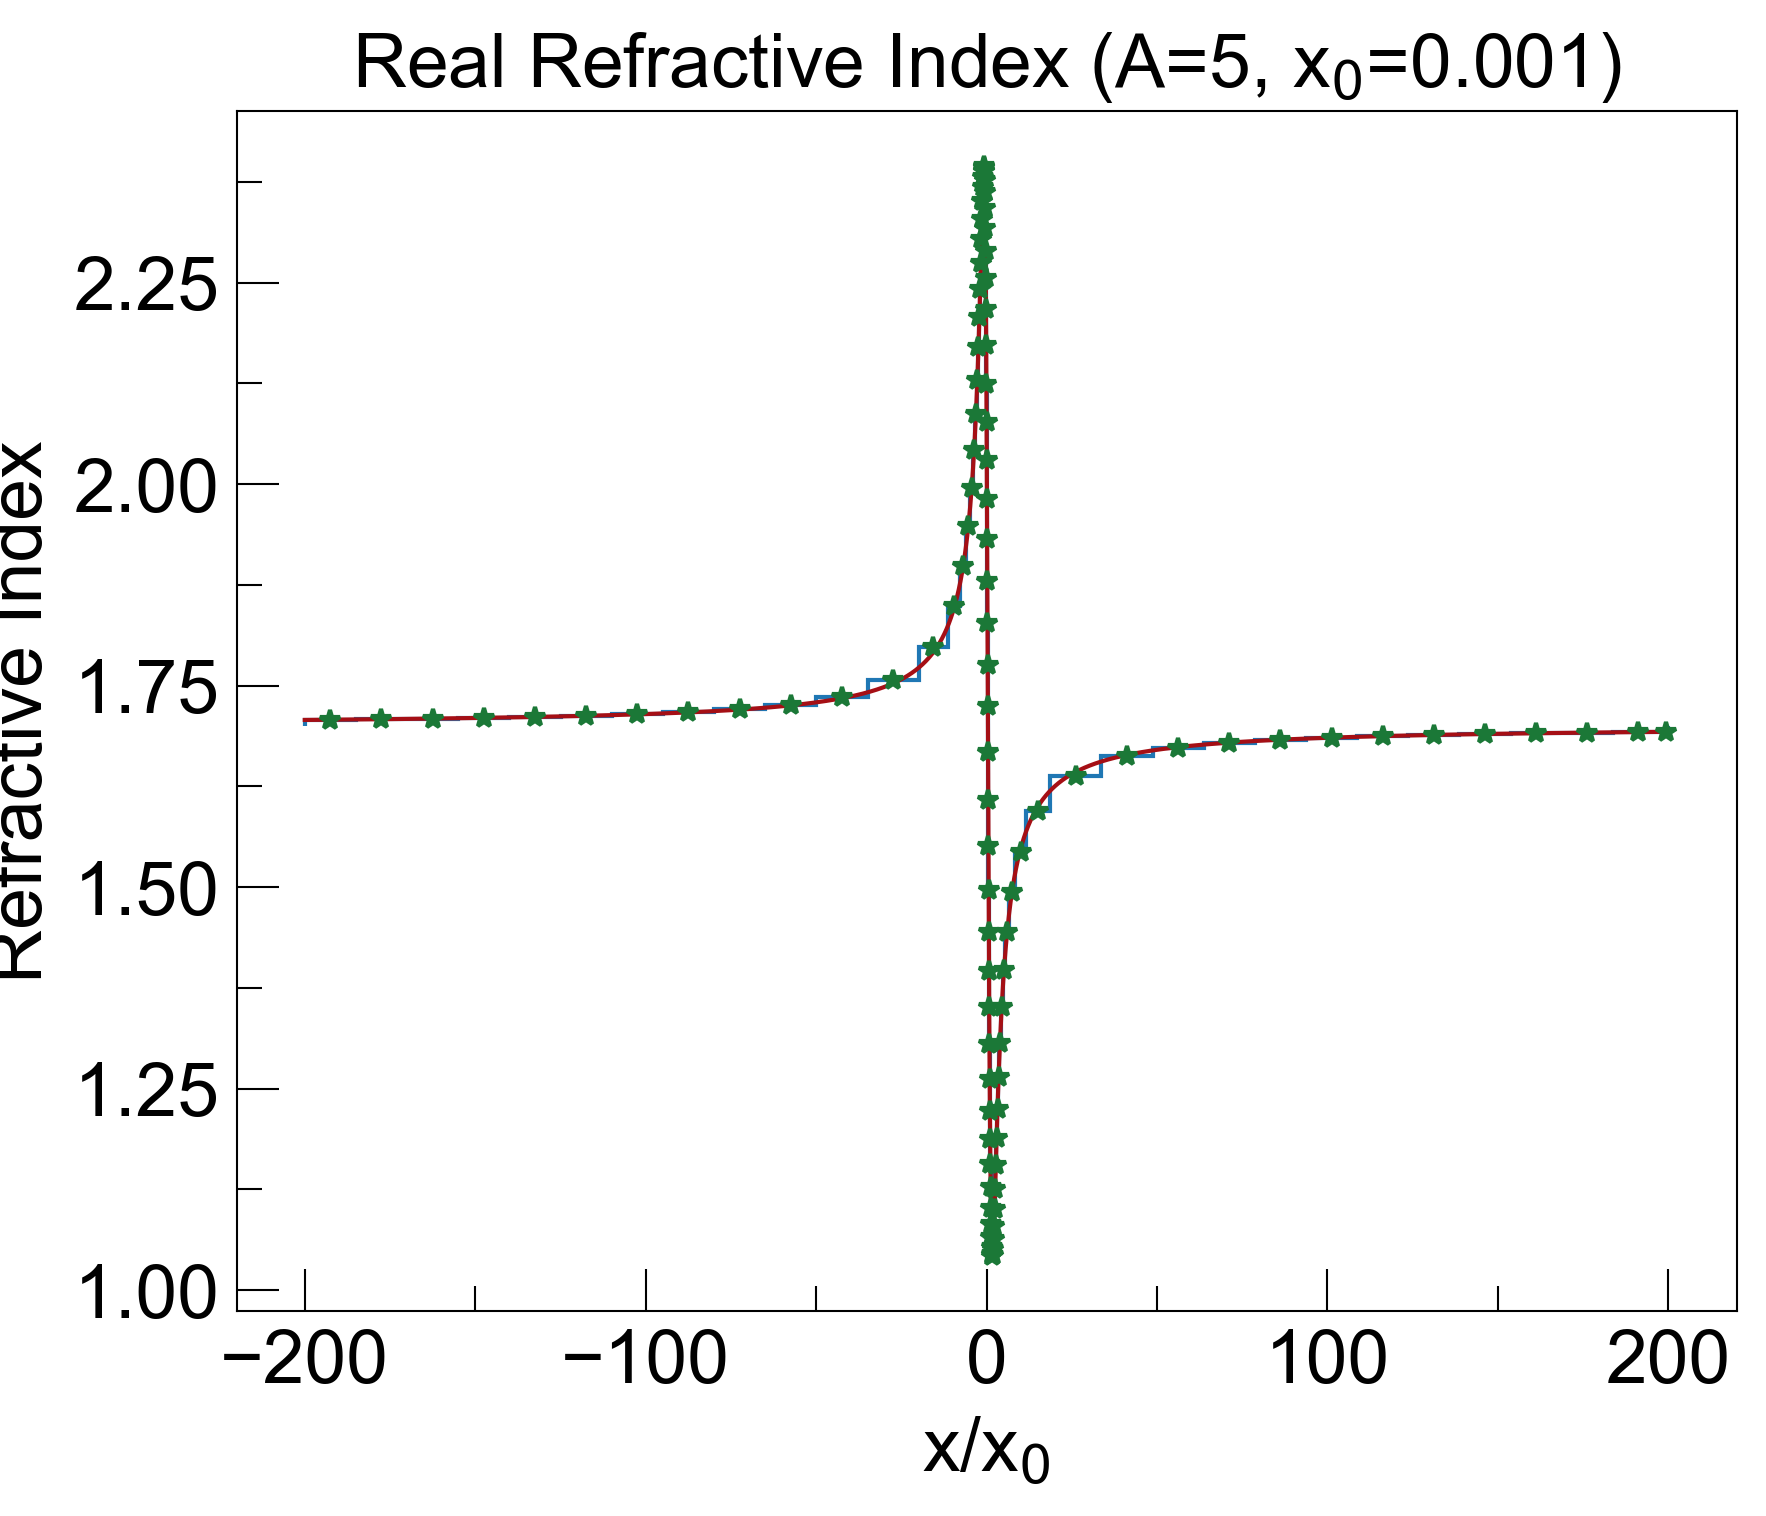

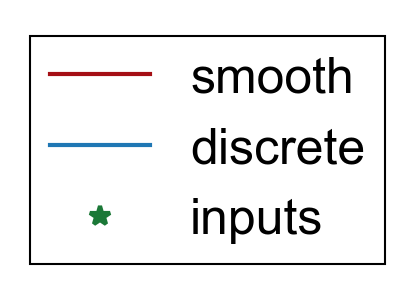

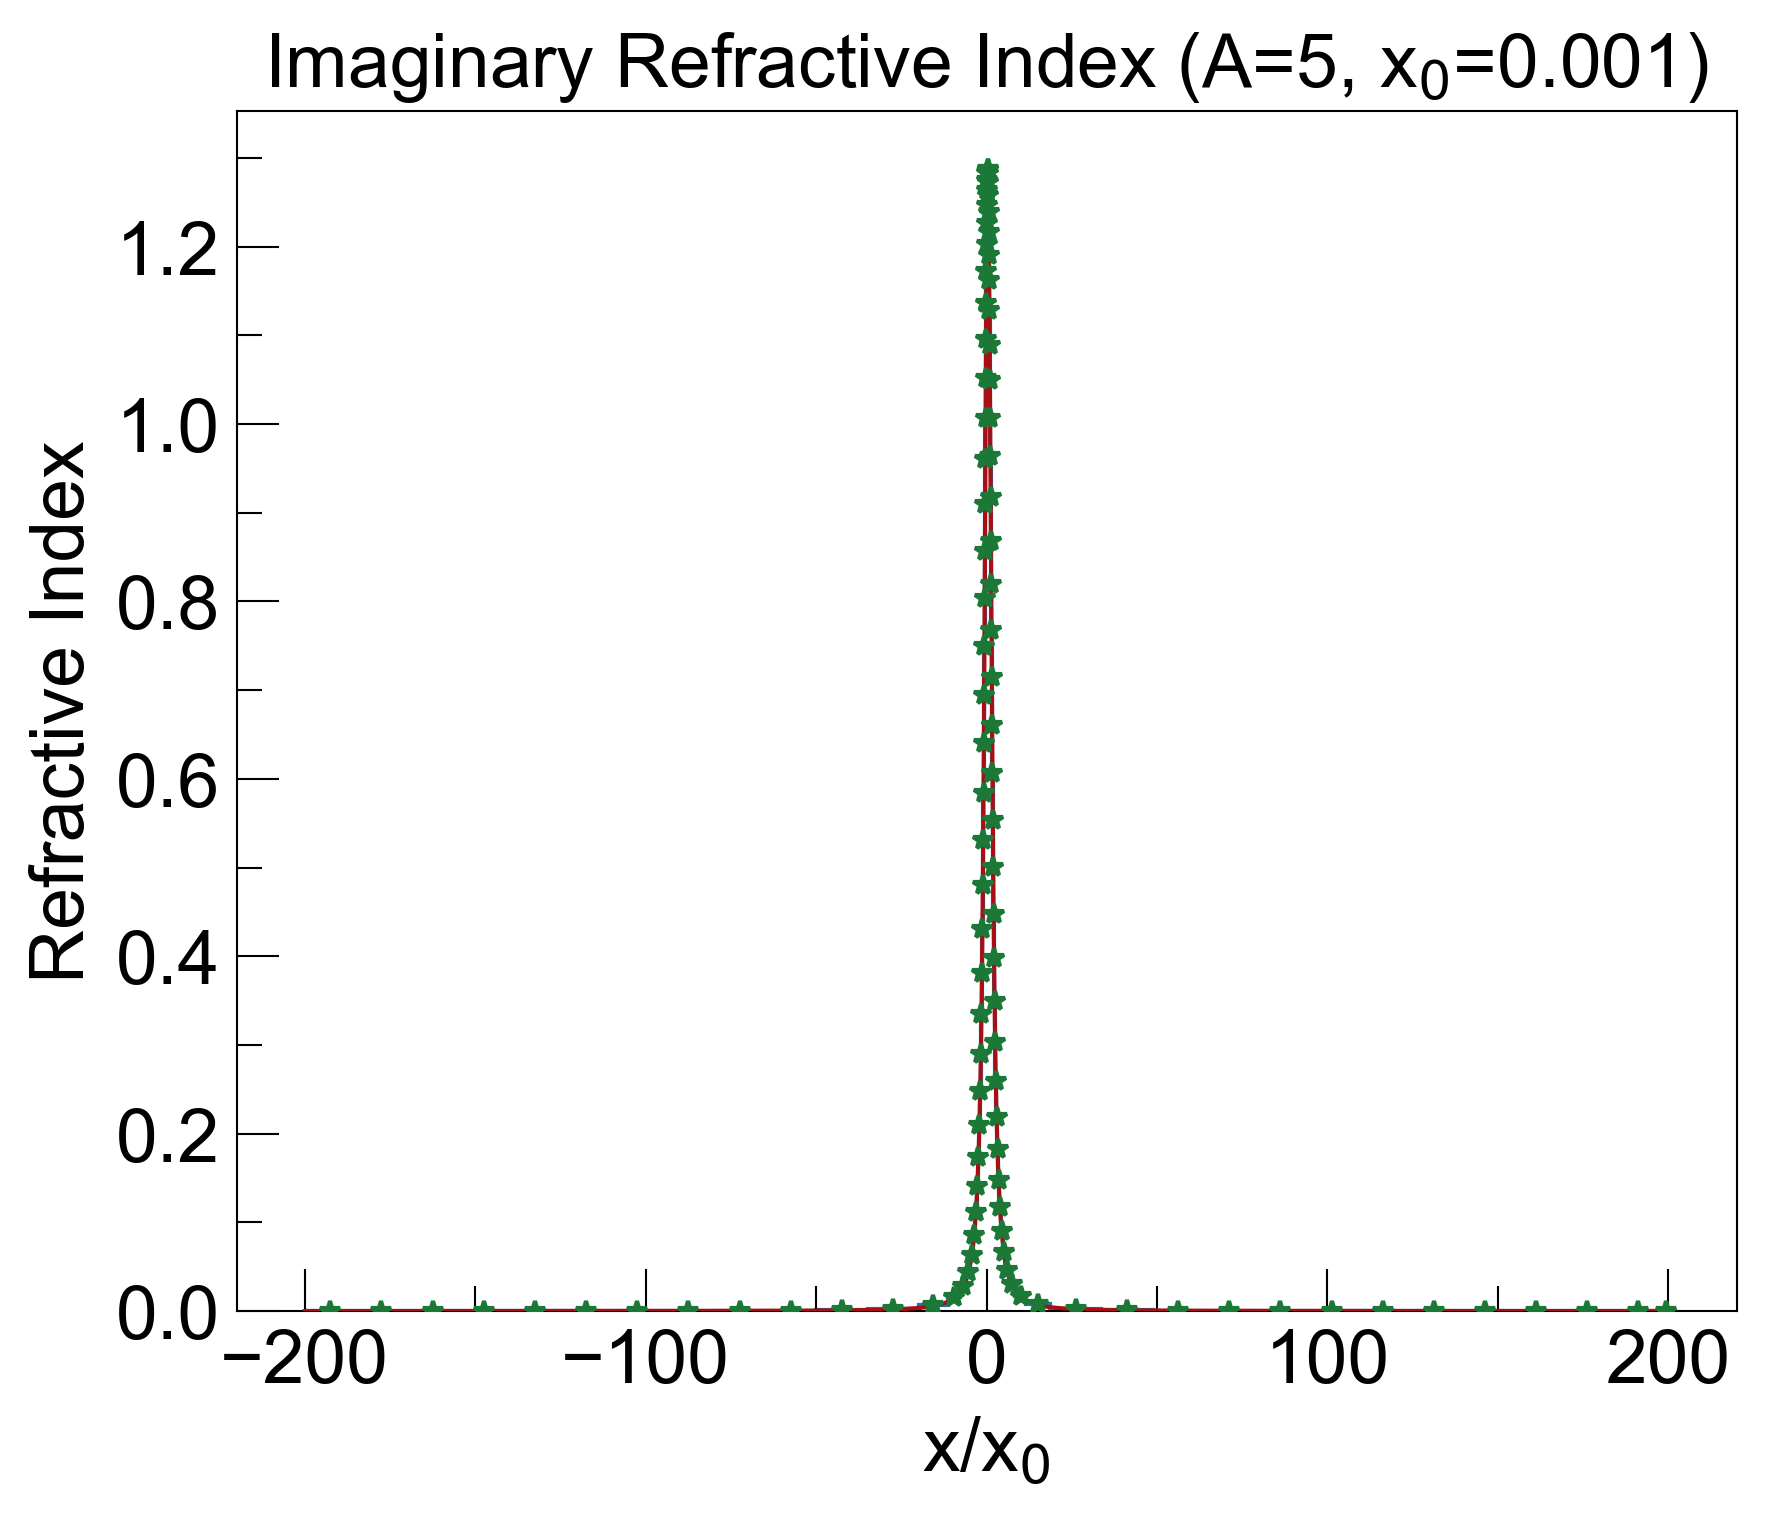

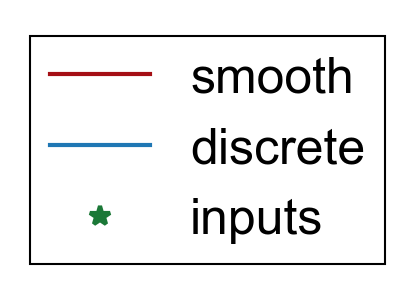

In [5]:
A = 5
gam = 0.001
nb = 1.7
n_list, d_list = generate_n_and_d(gam, A, nb, True)
print(len(n_list))
print(np.sum(d_list))

In [ ]:
def generate_StackofStacks(gam, a, nb, num_stacks, t_prop):
    n_list = []
    d_list = []
    c_list = []
    c_list_KK = []

    n_list_KK, d_list_KK = tmm_h.generate_n_and_d_v6_symmetry(gam, a, nb, delta=0.03, plot_flag=False)
    t_KK = np.sum(d_list_KK)
    t_inc = t_prop*t_KK
    print(f"t_KK is: {t_KK}")
    print(f"t_inc is: {t_inc}")
    t_total = num_stacks*(t_inc + t_KK)
    print(f"t_total is: {t_total}")
    #print(f'length of KK MS is: {t_KK}')

    k_bulk = np.sum(d_list_KK * np.imag(n_list_KK)) / t_KK
    print(f'k_bulk from np.sum is: {k_bulk}')
    losses_total = t_total * k_bulk
    print(f'total losses are: {losses_total}')

    for i in range(len(d_list_KK)):
        c_list_KK.append('c')

    for i in range(num_stacks):
        n_list.extend(n_list_KK)
        d_list.extend(d_list_KK)
        c_list.extend(c_list_KK)
        n_list.append(nb)
        d_list.append(t_inc)
        c_list.append('i')
    
    d_list.append(inf)
    d_list.insert(0, inf)
    n_list.append(nb)
    n_list.insert(0, nb)
    c_list.insert(0, 'i')
    c_list.append('i')


    return (n_list, d_list, c_list, losses_total)



In [7]:
# wavelength dependence calculation of RTA using incoherent TMM function (inc_tmm)

def TRA_func(n_list, d_list, c_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    angle = 0
    T_list = np.zeros_like(lambda_list)
    R_list = np.zeros_like(lambda_list)
    A_list = np.zeros_like(lambda_list)
    
    for j, lamb in enumerate(lambda_list):
        T_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['T']
        R_list[j] = tmm.inc_tmm(pol, n_list, d_list, c_list, angle, lamb)['R']
      #  T_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
      #  R_list[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list[j] = 1 - T_list[j] - R_list[j]

    return (T_list, R_list, A_list)
    

In [148]:
nkdata_sapphire = np.genfromtxt('lam_um_T_K_Al2O3_no_ko_ne_ke.dat')
kdata_sapphire = nkdata_sapphire[:451, 3]
ndata_sapphire = nkdata_sapphire[:451, 2]
lamdata_sapphire = nkdata_sapphire[:451, 0]
plt.figure(lamdata_sapphire, ndata_sapphire)
plt.plot(lamdata_sapphire, kdata_sapphire)
k_bulk = np.average(kdata_sapphire)
print(k_bulk)
n_list, d_list, c_list, losses_total = generate_StackofStacks(0.01, 0.01, 1.7, 2, 0)
print(n_list)
print(d_list)
print(c_list)

4.268238205980066e-06
t_KK is: 19.72175
t_inc is: 0.0
t_total is: 39.4435
k_bulk from np.sum is: 4.783392186631738e-06
total losses are: 0.00018867372971340896
[1.7, (1.7000030321347646+3.125909340822993e-09j), (1.7000031289380046+3.3286898003126126e-09j), (1.7000032320905976+3.551783563662285e-09j), (1.700003342276368+3.798080753971135e-09j), (1.7000034602807197+4.07101013932425e-09j), (1.7000035868789403+4.374344686703928e-09j), (1.7000037231395329+4.7130086661510464e-09j), (1.700003870161627+5.092580164417974e-09j), (1.7000040292725052+5.5199229127321635e-09j), (1.7000042019670438+6.003231446385206e-09j), (1.7000043901933302+6.553105743200021e-09j), (1.7000045960734964+7.1821406772387635e-09j), (1.700004822134332+7.906034287485178e-09j), (1.7000050716708128+8.745453248319652e-09j), (1.7000053484426867+9.726017481615722e-09j), (1.7000056571661772+1.0881240170344727e-08j), (1.700006003713123+1.2255205294525049e-08j), (1.7000063954880216+1.3906836547408005e-08j), (1.700006841963002+1.5

In [8]:
# calculate TRA of stack of stacks

#A = 0.00178063
A = 5
gam = 0.001
nb = 1.7
num_stacks = 50
t_prop = 0

n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, num_stacks, t_prop)

n_list_reversed = n_list[::-1]
d_list_reversed = d_list[::-1]
c_list_reversed = c_list[::-1]

T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
lambda_list = np.linspace(2,5,100)

trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk

n_list_KK, d_list_KK = generate_n_and_d(gam, A, nb, False)
losses_KK = np.sum(d_list_KK * np.imag(n_list_KK))
trans_KK_bulk = np.exp(-4*np.pi*losses_KK/lambda_list)
emiss_KK_bulk = 1 - trans_KK_bulk
c_list_KK = []
for i in range(len(d_list_KK)):
    c_list_KK.append('c')

d_list_KK.append(inf)
d_list_KK.insert(0, inf)
n_list_KK.append(nb)
n_list_KK.insert(0, nb)
c_list_KK.insert(0, 'i')
c_list_KK.append('i')

n_list_reversed_KK = n_list_KK[::-1]
d_list_reversed_KK = d_list_KK[::-1]
c_list_reversed_KK = c_list_KK[::-1]


T_list_LR_KK, R_list_LR_KK, A_list_LR_KK = TRA_func(n_list_KK, d_list_KK, c_list_KK)
T_list_RL_KK, R_list_RL_KK, A_list_RL_KK = TRA_func(n_list_reversed_KK, d_list_reversed_KK, c_list_reversed_KK)
#print(R_list_RL_KK)

T_list_analytic = T_list_LR_KK**num_stacks
geom_series = np.zeros_like(A_list_LR_KK)
for k in range(num_stacks):
    geom_series = geom_series + T_list_LR_KK**k
    
A_list_LR_analytic = A_list_LR_KK*geom_series
A_list_RL_analytic = A_list_RL_KK*geom_series
print(A_list_RL_analytic)


Number of Layers: 128
t_KK is: 0.4
t_inc is: 0.0
t_total is: 20.0
k_bulk from np.sum is: 0.011569306410369231
total losses are: 0.23138612820738463
[0.74501529 0.74052796 0.73606127 0.73161658 0.72719515 0.72279815
 0.71842665 0.71408163 0.70976398 0.7054745  0.70121393 0.69698293
 0.69278208 0.68861192 0.68447289 0.68036542 0.67628984 0.67224646
 0.66823554 0.66425728 0.66031185 0.65639938 0.65251997 0.64867367
 0.64486053 0.64108053 0.63733366 0.63361986 0.62993906 0.62629117
 0.62267608 0.61909366 0.61554376 0.61202621 0.60854085 0.60508748
 0.6016659  0.59827591 0.59491729 0.5915898  0.58829321 0.58502729
 0.58179177 0.57858641 0.57541094 0.57226511 0.56914864 0.56606127
 0.56300273 0.55997273 0.556971   0.55399726 0.55105124 0.54813264
 0.5452412  0.54237663 0.53953865 0.53672697 0.53394133 0.53118143
 0.528447   0.52573777 0.52305346 0.52039378 0.51775848 0.51514728
 0.51255991 0.5099961  0.50745559 0.50493811 0.5024434  0.49997121
 0.49752128 0.49509334 0.49268716 0.49030248 0.4

In [202]:
np.savetxt(f"C:\\Users\\kl89\\MS Window Project\\Data\\T_list_RL_A={A}_x0={gam}_N={num_stacks}.txt", T_list_RL)
np.savetxt(f"C:\\Users\\kl89\\MS Window Project\\Data\\T_list_analytic_A={A}_x0={gam}_N={num_stacks}.txt", T_list_analytic)
np.savetxt(f"C:\\Users\\kl89\\MS Window Project\\Data\\A_list_RL_A={A}_x0={gam}_N={num_stacks}.txt", A_list_RL)
np.savetxt(f"C:\\Users\\kl89\\MS Window Project\\Data\\A_list_RL_analytic_A={A}_x0={gam}_N={num_stacks}.txt", A_list_RL_analytic)

"\nplt.figure()\n#plt.plot(lambda_list,T_list_LR, label='T_LR')\n#print(T_list_LR/trans_bulk)\nplt.plot(lambda_list,T_list_RL, label='T_RL')\nplt.plot(lambda_list,T_list_analytic, '--', label='T_analytic')\n#plt.plot(lambda_list,T_list_LR_KK, label='T_LR_KK')\n#plt.plot(lambda_list,R_list_LR, label='R_LR')\n#plt.plot(lambda_list,A_list_LR, label='A_LR')\n#plt.plot(lambda_list,R_list_RL, label='R_RL')\nplt.plot(lambda_list,A_list_RL, label='A_RL')\nplt.plot(lambda_list,A_list_RL_analytic, '--', label='A_RL_analytic')\n#plt.plot(lambda_list,A_list_LR_analytic, '--', label='A_LR_analytic')\n#plt.plot(lambda_list,trans_bulk, '--', label='T_bulk')\n#plt.plot(lambda_list,emiss_bulk, '--', label='A_bulk')\nplt.xlabel('Wavelength ($\\mu$m)')\nplt.ylabel('Fraction of Power')\nplt.title(f'Transmittance and Emittance for N={num_stacks}')\nplt.legend(loc='center right')\n"

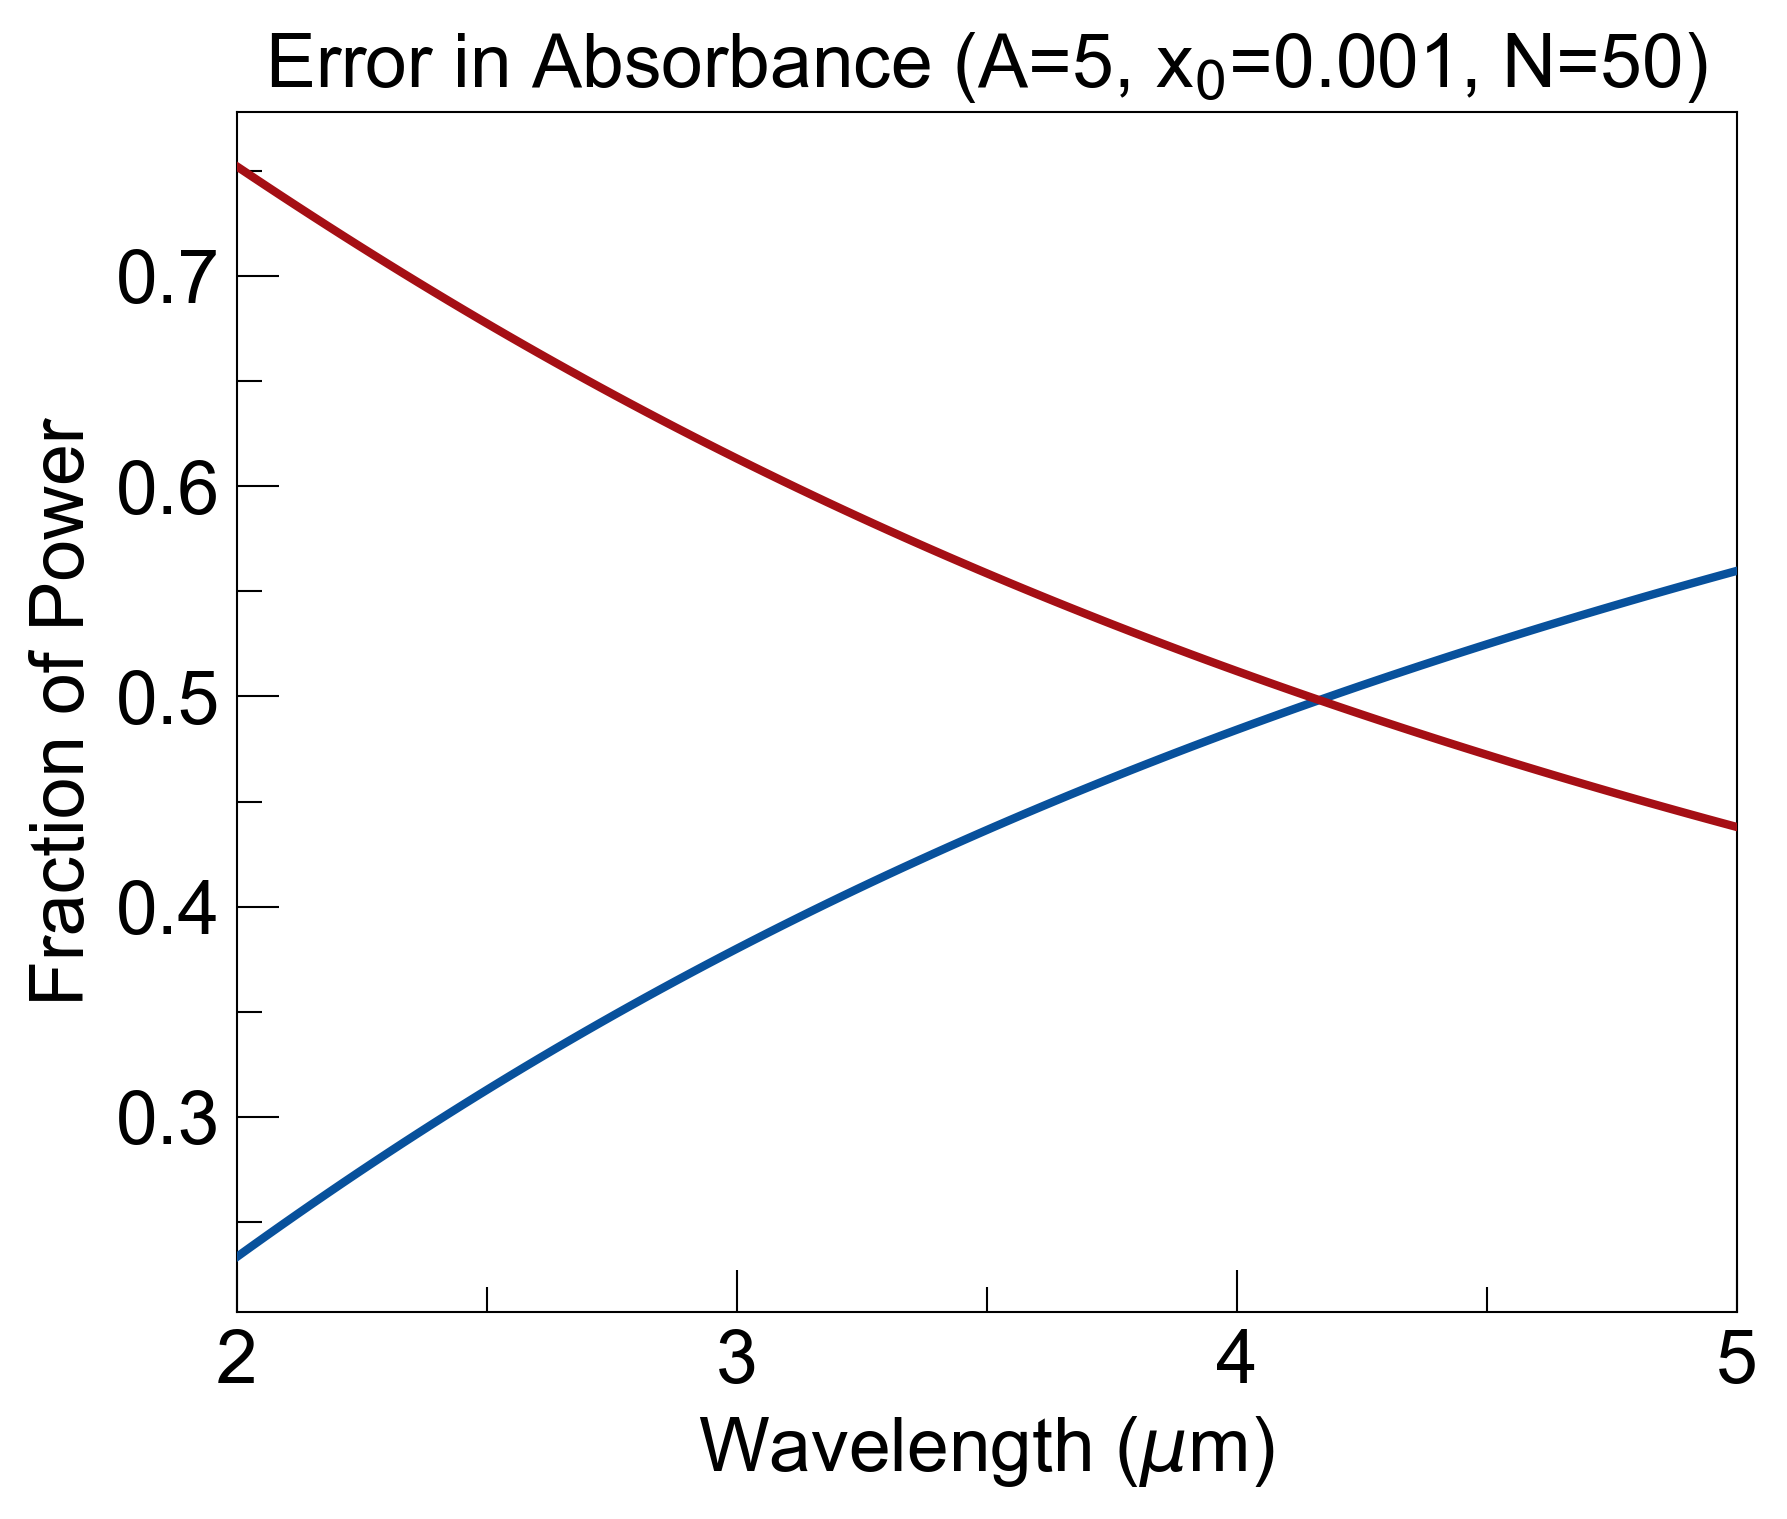

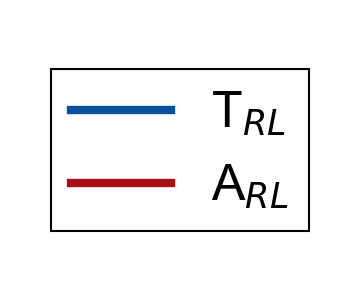

In [11]:
# plotting RTA forwards and backwards

savename = f'Abs_diff_A={A}_x0={gam}_N={num_stacks}'
xlabel = 'Wavelength ($\mu$m)'; ylabel = 'Fraction of Power'
title = f'Error in Absorbance (A={A}, x$_0$={gam}, N={num_stacks})'
fig,ax = plot_setup(xlabel,ylabel,title=title,xmin=lambda_list[0],xmax=lambda_list[-1],xstep=1,figsize=(5,4),auto_scale=True)
#plt.rcParams['figure.figsize'] = [2,1]
plot(fig,ax,lambda_list,T_list_RL,label=r'T$_{RL}$',color=colors.blue,auto_scale=True)
plot(fig,ax,lambda_list,A_list_RL,label=r'A$_{RL}$',color=colors.red,auto_scale=True)
#plot(fig,ax,lambda_list,T_list_analytic, '--', label=r'T$_{analytic}$',color=colors.light_blue,auto_scale=True)
#plot(fig,ax,lambda_list,A_list_RL_analytic,label=r'A$_{analytic}$',color=colors.red,auto_scale=True)
#plot(fig,ax,lambda_list,trans_bulk, '--', label=r'trans_bulk',color=colors.red,auto_scale=True)
small_term = A_list_LR_KK*R_list_RL_KK*T_list_LR_KK
#plot(fig,ax,lambda_list,A_list_RL-A_list_RL_analytic,label=r'A$_{{TMM}}$ - A$_{{analytic}}$',color=colors.blue,auto_scale=True)
#plot(fig,ax,lambda_list,small_term, '--', label=r'A$_{LR}$R$_{RL}$T',color=colors.light_red,auto_scale=True)
#plot(fig,ax,lambda_list,A_list_RL_analytic, '--', label=r'A$_{RL,analytic}$',color=colors.light_red,auto_scale=True)
#plot(fig,ax,lambda_list,emiss_bulk, '--', label=r'emiss_bulk',color=colors.light_purple,auto_scale=True)

#plot(fig,ax,lambda_list,R_list_RL,label=r'R$_{RL}$',color=colors.green,auto_scale=True)
#plot(fig,ax,lambda_list,R_list_LR, '--', label=r'R$_{LR}$',color=colors.light_purple,auto_scale=True)

plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi) # save figure as image file

# Create and save legend for above figure
legend(fig,ax,auto_scale=True) # create legend from curves labeled above
plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi) # save legend as image file


'''
plt.figure()
#plt.plot(lambda_list,T_list_LR, label='T_LR')
#print(T_list_LR/trans_bulk)
plt.plot(lambda_list,T_list_RL, label='T_RL')
plt.plot(lambda_list,T_list_analytic, '--', label='T_analytic')
#plt.plot(lambda_list,T_list_LR_KK, label='T_LR_KK')
#plt.plot(lambda_list,R_list_LR, label='R_LR')
#plt.plot(lambda_list,A_list_LR, label='A_LR')
#plt.plot(lambda_list,R_list_RL, label='R_RL')
plt.plot(lambda_list,A_list_RL, label='A_RL')
plt.plot(lambda_list,A_list_RL_analytic, '--', label='A_RL_analytic')
#plt.plot(lambda_list,A_list_LR_analytic, '--', label='A_LR_analytic')
#plt.plot(lambda_list,trans_bulk, '--', label='T_bulk')
#plt.plot(lambda_list,emiss_bulk, '--', label='A_bulk')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power')
plt.title(f'Transmittance and Emittance for N={num_stacks}')
plt.legend(loc='center right')
'''

In [10]:
# calculate FOM_KK and equivalently lossy bulk

delta_lamb = lambda_list[-1] - lambda_list[0]
FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
#np.trapz(T2[:,j], x=lambda_list)**2 / np.trapz(A2_RL[:,j], x=lambda_list) / delta_lamb
FOM_RL_analytic = (np.trapz(T_list_analytic, x=lambda_list))**2 / np.trapz(A_list_RL_analytic, x=lambda_list) / delta_lamb
FOM_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

FOM_RL_KK = (np.trapz(T_list_RL_KK, x=lambda_list))**2 / np.trapz(A_list_RL_KK, x=lambda_list) / delta_lamb
FOM_bulk_KK = (np.trapz(trans_KK_bulk, x=lambda_list))**2 / np.trapz(emiss_KK_bulk, x=lambda_list) / delta_lamb
print(f'FOM_LR is: {FOM_LR}')
print(f'FOM_RL is: {FOM_RL}')
print(f'FOM_RL_analytic is: {FOM_RL_analytic}')
print(f'FOM_bulk is: {FOM_bulk}')
print(f'FOM enhancement TMM is: {FOM_RL/FOM_bulk}')
print(f'FOM enhancement semi-analytical is: {FOM_RL_analytic/FOM_bulk}')
print(f'Average T is: {np.trapz(T_list_LR, x=lambda_list) / delta_lamb}')

print(f'FOM for 1 KK: {FOM_RL_KK}')
print(f'FOM for 1 bulk: {FOM_bulk_KK}')
print(f'FOM enhancement for 1: {FOM_RL_KK/FOM_bulk_KK}')
print(f'FOM for 2 KK: {FOM_RL}')
print(f'FOM for 2 bulk: {FOM_bulk}')
print(f'FOM enhancement for {num_stacks}: {FOM_RL/FOM_bulk}')

FOM_LR is: 0.3105466985824002
FOM_RL is: 0.31373958890919657
FOM_RL_analytic is: 0.31168147750243397
FOM_bulk is: 0.30936196160412804
FOM enhancement TMM is: 1.0141505028038007
FOM enhancement semi-analytical is: 1.0074977411129622
Average T is: 0.42318909886244405
FOM for 1 KK: 55.53136506015408
FOM for 1 bulk: 54.57503201590106
FOM enhancement for 1: 1.017523270421067
FOM for 2 KK: 0.31373958890919657
FOM for 2 bulk: 0.30936196160412804
FOM enhancement for 50: 1.0141505028038007


In [9]:
# TMM only sweep over ampiltude A, width gamma, and number of layers

#A = 0.1
#A_arr = np.arange(1, 6, 1)
A_arr = [0.1, 1, 5, 10]
print(A_arr)
#gam = 0.0005
#gam_arr = np.arange(0.0001, 0.0011, 0.0001)
gam_arr = [0.0001, 0.0005, 0.001, 0.01]
print(gam_arr)
nb = 1.7
t_prop = 0
num_stacks_arr = np.arange(1, 200, 10)
print(num_stacks_arr)
length = len(num_stacks_arr)
FOM_LR_arr = np.empty((len(A_arr), len(gam_arr), length), dtype=float)
FOM_RL_arr = np.empty((len(A_arr), len(gam_arr), length), dtype=float)
FOM_bulk_arr = np.empty((len(A_arr), len(gam_arr), length), dtype=float)

for i, A in enumerate(A_arr):
    print(f'A is: {A}')
    for j, gam in enumerate(gam_arr):
        print(f'gam is: {gam}')
        for k, n in enumerate(num_stacks_arr):
            print(f'num of stacks is: {n}')
            n_list, d_list, c_list, losses_total = generate_StackofStacks(gam, A, nb, n, t_prop)
            n_list_reversed = n_list[::-1]
            d_list_reversed = d_list[::-1]
            c_list_reversed = c_list[::-1]

            T_list_LR, R_list_LR, A_list_LR = TRA_func(n_list, d_list, c_list)
            T_list_RL, R_list_RL, A_list_RL = TRA_func(n_list_reversed, d_list_reversed, c_list_reversed)
            lambda_list = np.linspace(2,5,100)
            delta_lamb = lambda_list[-1] - lambda_list[0]
            trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
            emiss_bulk = 1 - trans_bulk

            FOM_LR_arr[i][j][k] = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
            FOM_RL_arr[i][j][k] = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
            FOM_bulk_arr[i][j][k] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

    

[0.1, 1, 5, 10]
[0.0001, 0.0005, 0.001, 0.01]
[  1  11  21  31  41  51  61  71  81  91 101 111 121 131 141 151 161 171
 181 191]
A is: 0.1
gam is: 0.0001
num of stacks is: 1
t_KK is: 0.04
t_inc is: 0.0
t_total is: 0.04
k_bulk from np.sum is: 0.00023835704431003307
total losses are: 9.534281772401322e-06
num of stacks is: 11
t_KK is: 0.04
t_inc is: 0.0
t_total is: 0.44
k_bulk from np.sum is: 0.00023835704431003307
total losses are: 0.00010487709949641454
num of stacks is: 21
t_KK is: 0.04
t_inc is: 0.0
t_total is: 0.84
k_bulk from np.sum is: 0.00023835704431003307
total losses are: 0.00020021991722042777
num of stacks is: 31
t_KK is: 0.04
t_inc is: 0.0
t_total is: 1.24
k_bulk from np.sum is: 0.00023835704431003307
total losses are: 0.000295562734944441
num of stacks is: 41
t_KK is: 0.04
t_inc is: 0.0
t_total is: 1.6400000000000001
k_bulk from np.sum is: 0.00023835704431003307
total losses are: 0.0003909055526684543
num of stacks is: 51
t_KK is: 0.04
t_inc is: 0.0
t_total is: 2.04
k_bulk

In [10]:
# save above results

np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_bulk_num1~200_A0.1,1,5,10_gam0.0001,0.0005,0.001,0.01.npy", FOM_bulk_arr)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_LR_num1~200_A0.1,1,5,10_gam0.0001,0.0005,0.001,0.01.npy", FOM_LR_arr)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_RL_num1~200_A0.1,1,5,10_gam0.0001,0.0005,0.001,0.01.npy", FOM_RL_arr)

In [ ]:
# plot above results
color_arr = [colors.blue, colors.red, colors.green, colors.purple]
xlabel = 'Number of Stacks'
for i, A in enumerate(A_arr):
    for j, gam in enumerate(gam_arr):
        ylabel = 'Enhancement'
        gam_rounded = round(gam,4)
        savename = f'FOM_enhancement_vs_numStacks_A~{A}_gam~{gam_rounded}'
        title = f'FOM Enhancement (A={A}, x$_0$={gam_rounded})'
        fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)
        plot(fig,ax,num_stacks_arr,FOM_RL_arr[i,j,:]/FOM_bulk_arr[i,j,:],color=colors.blue, auto_scale=True)
        plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)

        ylabel = 'FOM'
        savename = f'FOM_KK_log_vs_numStacks_A~{A}_gam~{gam_rounded}'
        title = f'Log of FOM KK (A={A}, x$_0$={gam_rounded})'
        fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)
        plot(fig,ax,num_stacks_arr,np.log(FOM_RL_arr[i,j,:]), color=colors.blue, auto_scale=True)
        plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)

    #legend(fig,ax,auto_scale=True)
    #plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi)



In [27]:
for i, A in enumerate(A_arr):
    for j, gam in enumerate(gam_arr):
        print(f"minimum for A={A}, gam={gam}: {np.argmin(FOM_RL_arr[i,j,:]/FOM_bulk_arr[i,j,:])}")

minimum for A=0.1, gam=0.0001: 0
minimum for A=0.1, gam=0.0005: 19
minimum for A=0.1, gam=0.001: 19
minimum for A=0.1, gam=0.01: 19
minimum for A=1, gam=0.0001: 0
minimum for A=1, gam=0.0005: 13
minimum for A=1, gam=0.001: 19
minimum for A=1, gam=0.01: 19
minimum for A=5, gam=0.0001: 0
minimum for A=5, gam=0.0005: 3
minimum for A=5, gam=0.001: 6
minimum for A=5, gam=0.01: 19
minimum for A=10, gam=0.0001: 0
minimum for A=10, gam=0.0005: 1
minimum for A=10, gam=0.001: 3
minimum for A=10, gam=0.01: 19


: 

In [ ]:
# Semi-analytical sweep over ampiltude A, width gamma, and number of layers
# to compare and debug above calculation

#A = 0.1
A_arr = np.arange(1, 6, 1)
print(A_arr)
#gam = 0.0005
gam_arr = np.arange(0.0001, 0.0011, 0.0001)
print(gam_arr)
nb = 1.7
t_prop = 0
num_stacks_arr = np.arange(1, 52, 5)
print(num_stacks_arr)
length = len(num_stacks_arr)
FOM_LR_arr_analytic = np.empty((len(A_arr), len(gam_arr), length), dtype=float)
FOM_RL_arr_analytic = np.empty((len(A_arr), len(gam_arr), length), dtype=float)
FOM_bulk_arr_analytic = np.empty((len(A_arr), len(gam_arr), length), dtype=float)

for i, A in enumerate(A_arr):
    print(f'A is: {A}')
    for j, gam in enumerate(gam_arr):
        print(f'gam is: {gam}')

        n_list_KK, d_list_KK = generate_n_and_d(gam, A, nb, False)
        c_list_KK = []
        for m in range(len(d_list_KK)):
            c_list_KK.append('c')

        t_KK = np.sum(d_list_KK)
        t_inc = t_prop*t_KK
        print(f"t_KK is: {t_KK}")
        print(f"t_inc is: {t_inc}")
        k_bulk = np.sum(d_list_KK * np.imag(n_list_KK)) / t_KK
        print(f'k_bulk from np.sum is: {k_bulk}')

        d_list_KK.append(inf)
        d_list_KK.insert(0, inf)
        n_list_KK.append(nb)
        n_list_KK.insert(0, nb)
        c_list_KK.insert(0, 'i')
        c_list_KK.append('i')
        
        n_list_reversed_KK = n_list_KK[::-1]
        d_list_reversed_KK = d_list_KK[::-1]
        c_list_reversed_KK = c_list_KK[::-1]


        T_list_LR_KK, R_list_LR_KK, A_list_LR_KK = TRA_func(n_list_KK, d_list_KK, c_list_KK)
        T_list_RL_KK, R_list_RL_KK, A_list_RL_KK = TRA_func(n_list_reversed_KK, d_list_reversed_KK, c_list_reversed_KK)

        for k, n in enumerate(num_stacks_arr):
            print(f'num of stacks is: {n}')

            t_total = n*(t_inc + t_KK)
            print(f"t_total is: {t_total}")
            losses_total = t_total * k_bulk
            print(f'total losses are: {losses_total}')
            
            T_list_analytic = T_list_LR_KK**n
            geom_series = np.zeros_like(A_list_LR_KK)
            for l in range(n):
                geom_series = geom_series + T_list_LR_KK**l
                
            A_list_LR_analytic = A_list_LR_KK*geom_series
            A_list_RL_analytic = A_list_RL_KK*geom_series

            #######################################################################

            lambda_list = np.linspace(2,5,100)
            delta_lamb = lambda_list[-1] - lambda_list[0]
            trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
            emiss_bulk = 1 - trans_bulk

            FOM_LR_arr_analytic[i][j][k] = (np.trapz(T_list_analytic, x=lambda_list))**2 / np.trapz(A_list_LR_analytic, x=lambda_list) / delta_lamb
            FOM_RL_arr_analytic[i][j][k] = (np.trapz(T_list_analytic, x=lambda_list))**2 / np.trapz(A_list_RL_analytic, x=lambda_list) / delta_lamb
            FOM_bulk_arr_analytic[i][j][k] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

In [102]:
# save above results

np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_bulk_analytic_num1~50_A0-1~5_gam0-0001~0.001.npy", FOM_bulk_arr_analytic)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_LR_analytic_num1~50_A0-1~5_gam0-0001~0.001.npy", FOM_LR_arr_analytic)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_RL_analytic_num1~50_A0-1~5_gam0-0001~0.001.npy", FOM_RL_arr_analytic)

In [ ]:
savename = f'FOM_RL_and_bulk_vs_numStacks_A~5_gam~0.001_TMM_vs_analytical'
xlabel = 'Number of Stacks'; ylabel = 'Enhancement'
title = f'FOM (A=5, x$_0$=0.001)'
fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)
j = len(A_arr)-1
i = len(gam_arr)-1
plot(fig,ax,num_stacks_arr,FOM_RL_arr[j,i,:], label=f'KK,TMM', color=colors.blue,auto_scale=True)
plot(fig,ax,num_stacks_arr,FOM_RL_arr_analytic[j,i,:], label=f'KK,Analytic', color=colors.green,auto_scale=True)
plot(fig,ax,num_stacks_arr,FOM_bulk_arr[j,i,:], '--', label=f'bulk,TMM', color=colors.light_blue,auto_scale=True)
plot(fig,ax,num_stacks_arr,FOM_bulk_arr_analytic[j,i,:], '--', label=f'bulk,Analytic', color=colors.light_green,auto_scale=True)
plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)
legend(fig,ax,auto_scale=True) # create legend from curves labeled above
plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi) # save legend as image file

In [ ]:
for i, gam in enumerate(gam_arr):
    savename = f'FOMEnhancement_vs_numStacks_and_A_gam~{round(gam, 4)}_pureTMM'
    xlabel = 'Number of Stacks'; ylabel = 'Enhancement'
    title = f'FOM Enhancement (x$_0$={gam})'
    fig,ax = plot_setup(xlabel,ylabel,title=title,figsize=(5,4),auto_scale=True)
    for j, A in enumerate(A_arr):
        plot(fig,ax,num_stacks_arr,FOM_RL_arr[j,i,:]/FOM_bulk_arr[j,i,:], label=f'A={A}',auto_scale=True)

    legend(fig,ax,auto_scale=True) # create legend from curves labeled above
    plt.savefig(fig_dir+savename+'legend'+fmt, bbox_inches='tight', transparent=True, dpi=dpi) # save legend as image file
    plt.savefig(fig_dir+savename+fmt,bbox_inches='tight',transparent=False,dpi=dpi)

In [108]:
# plot above results

for i, gam in enumerate(gam_arr):
    plt.figure()
    for j, A in enumerate(A_arr):
        plt.plot(num_stacks_arr, FOM_RL_arr_analytic[j,i,:]/FOM_bulk_arr_analytic[j,i,:], label=f'A={A}')
    plt.ylabel('Enhancement')
    plt.xlabel('Number of Stacks')
    plt.title(f'FOM Enhancement for x0 = {round(gam, 4)}')
    plt.legend(loc='lower left')
    plt.savefig(f"C:\\Users\\kl89\\MS Window Project\\Figures\\FOM_vs_numStacks_and_A_gam~{round(gam, 4)}_semi-analytical.png")

In [109]:
# only for when sweeping A, gam, and num_stacks

for i, gam in enumerate(gam_arr): 
    plt.figure(i)
    for j, A in enumerate(A_arr):
        plt.plot(num_stacks_arr, FOM_RL_arr_analytic[j, i, :], '*-', label=f'KK, A={A}')
        plt.plot(num_stacks_arr, FOM_bulk_arr_analytic[j, i, :], '*-', label=f'bulk, A={A}')
    plt.title(f"FOM Enhancement (x0 = {round(gam, 4)})")
    plt.legend(loc='upper right')
    plt.xlabel("number of stacks")
    plt.ylabel('enhancement')

In [ ]:
# Semi-analytical sweep over amplitude A and number of layers N (fix gamma)

gam = 0.0002
#A = 0.1
A_arr = np.arange(1, 100, 1)
#gam_arr = np.arange(0.0001, 0.0011, 0.0001)
#print(gam_arr)
nb = 1.7
t_prop = 0
num_stacks_arr = np.arange(1, 1000, 1)
length = len(num_stacks_arr)
FOM_LR_arr_analytic = np.empty((len(A_arr), length), dtype=float)
FOM_RL_arr_analytic = np.empty((len(A_arr), length), dtype=float)
FOM_bulk_arr_analytic = np.empty((len(A_arr), length), dtype=float)

for i, A in enumerate(A_arr):
    print(f'A is: {A}')

    n_list_KK, d_list_KK = generate_n_and_d(gam, A, nb, False)
    c_list_KK = []
    for m in range(len(d_list_KK)):
        c_list_KK.append('c')

    t_KK = np.sum(d_list_KK)
    t_inc = t_prop*t_KK
    print(f"t_KK is: {t_KK}")
    print(f"t_inc is: {t_inc}")
    k_bulk = np.sum(d_list_KK * np.imag(n_list_KK)) / t_KK
    print(f'k_bulk from np.sum is: {k_bulk}')

    d_list_KK.append(inf)
    d_list_KK.insert(0, inf)
    n_list_KK.append(nb)
    n_list_KK.insert(0, nb)
    c_list_KK.insert(0, 'i')
    c_list_KK.append('i')
    
    n_list_reversed_KK = n_list_KK[::-1]
    d_list_reversed_KK = d_list_KK[::-1]
    c_list_reversed_KK = c_list_KK[::-1]


    T_list_LR_KK, R_list_LR_KK, A_list_LR_KK = TRA_func(n_list_KK, d_list_KK, c_list_KK)
    T_list_RL_KK, R_list_RL_KK, A_list_RL_KK = TRA_func(n_list_reversed_KK, d_list_reversed_KK, c_list_reversed_KK)

    for j, n in enumerate(num_stacks_arr):
        print(f'num of stacks is: {n}')

        t_total = n*(t_inc + t_KK)
        print(f"t_total is: {t_total}")
        losses_total = t_total * k_bulk
        print(f'total losses are: {losses_total}')
        
        T_list_analytic = T_list_LR_KK**n
        geom_series = np.zeros_like(A_list_LR_KK)
        for l in range(n):
            geom_series = geom_series + T_list_LR_KK**l
            
        A_list_LR_analytic = A_list_LR_KK*geom_series
        A_list_RL_analytic = A_list_RL_KK*geom_series

        #######################################################################

        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk

        FOM_LR_arr_analytic[i][j] = (np.trapz(T_list_analytic, x=lambda_list))**2 / np.trapz(A_list_LR_analytic, x=lambda_list) / delta_lamb
        FOM_RL_arr_analytic[i][j] = (np.trapz(T_list_analytic, x=lambda_list))**2 / np.trapz(A_list_RL_analytic, x=lambda_list) / delta_lamb
        FOM_bulk_arr_analytic[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

    

In [169]:
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_bulk_analytic_fixed_StackofStacks_num1~1000_A0-1~100_gam0-0002.npy", FOM_bulk_arr_analytic)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_LR_analytic_fixed_StackofStacks_num1~1000_A0-1~100_gam0-0002.npy", FOM_LR_arr_analytic)
np.save("C:\\Users\\kl89\\MS Window Project\\Data\\FOM_RL_analytic_fixed_StackofStacks_num1~1000_A0-1~100_gam0-0002.npy", FOM_RL_arr_analytic)

In [170]:
# Plot enhancement as a colorplot

plt.figure()
plt.imshow(np.log(FOM_RL_arr_analytic/FOM_bulk_arr_analytic), interpolation='none', aspect='auto', origin='lower', extent=[num_stacks_arr[0], num_stacks_arr[-1],
    A_arr[0], A_arr[-1]])
plt.colorbar(label="log(FoM)")
plt.ylabel('Amplitude A')
plt.xlabel('Number of Stacks')
plt.title('Log of FoM Enhancement (gamma=0.0002)')

Text(0.5, 1.0, 'Log of FoM Enhancement (gamma=0.0002)')

In [ ]:
# Plot enhancement against num stacks for set A

A_set = 1
plt.figure()
plt.plot(num_stacks_arr, np.log(FOM_RL_arr_analytic[A_set, :] / FOM_bulk_arr_analytic[A_set, :]))
plt.ylabel('Log of Enhancement')
plt.xlabel('Number of Stacks N')
plt.title(f'Log of FoM Enhancement (gamma=0.0002), A={A_set}')

In [ ]:
# Plot enhancement against A for set num stacks

num_stacks_set = 500

plt.figure()
plt.plot(A_arr, np.log(FOM_RL_arr_analytic[:, num_stacks_set] / FOM_bulk_arr_analytic[:, num_stacks_set]))
plt.ylabel('Log of Enhancement')
plt.xlabel('Amplitude A')
plt.title(f'Log of FoM Enhancement (gamma=0.001), num_stacks={num_stacks_set}')

In [129]:
# Color Plot of Number of Stacks vs. FOM and A

plt.figure()
#plt.imshow(np.log(FOM_RL_arr_analytic/FOM_bulk_arr_analytic), interpolation='none', aspect='auto', origin='lower')
ratio = np.log(FOM_RL_arr_analytic / FOM_bulk_arr_analytic)

# Create arrays for x (i values), y (FOM[i][j] values), and color (j values)
x = np.repeat(np.arange(ratio.shape[0]), ratio.shape[1])  # Repeat i for each j
y = ratio.flatten()  # Flatten the array to get the FOM[i][j] values
colors = np.tile(np.arange(ratio.shape[1]), ratio.shape[0])  # Repeat j for each i

# Plot using scatter with colors representing j
plt.scatter(x, y, c=colors, cmap='viridis', marker='.')
plt.colorbar(label="Number of Stacks")  # Colorbar shows the index j

# Set labels
plt.xlabel("Amplitude A")
plt.ylabel("Log of FoM Enhancement")
plt.title("Number of Stacks Needed Given an FoM and Amplitude")

Text(0.5, 1.0, 'Number of Stacks Needed Given an FoM and Amplitude')

In [164]:
############################ SINGLE CONTOUR PLOT CODE ###########################

plt.figure()
# Assuming FOM_RL_arr_analytic and FOM_bulk_arr_analytic are your 2D arrays
FOM = np.log(FOM_RL_arr_analytic / FOM_bulk_arr_analytic)

# Interpolate FOM[i][j] for a specific FOM value (e.g., FOM = 2)
desired_FOM = 0.1
# Initialize a list to store the N values for the desired FOM
N_values_for_FOM = []

# Iterate through each value of A and find the closest N that gives the desired FOM
for a in A_arr:
    # Find the index of the closest FOM value to the desired FOM
    idx = np.argmin(np.abs(FOM[int((a - A_arr[0]) / (A_arr[1] - A_arr[0]))] - desired_FOM))
    N_values_for_FOM.append(num_stacks_arr[idx])

plt.plot(A_arr, N_values_for_FOM)
plt.xlabel("Amplitude A")
plt.ylabel("Number of stacks N")
plt.title(f"log(FoM) = {desired_FOM}")
plt.grid(True)
plt.show()


In [167]:
#################### CONTOUR PLOT CODE ##############################

# Assuming FOM_RL_arr_analytic and FOM_bulk_arr_analytic are your 2D arrays
FOM = FOM_RL_arr_analytic / FOM_bulk_arr_analytic

# Create a meshgrid for the contour plot
A_grid, N_grid = np.meshgrid(A_arr, num_stacks_arr)

FOM_transposed = FOM.T

# Create an inverted contour plot: contour levels will correspond to N values
plt.figure(figsize=(10, 8))

# Use 'contour' to plot the contours, and we set levels to correspond to specific N values
# We will create the contours for FOM values, but the color scale will correspond to N values.
# We assume FOM[i, j] corresponds to FOM at (A[i], N[j])

# Plot contours for specific FOM levels (can be adjusted as needed)
print(np.min(FOM_transposed))
contour = plt.contour(A_grid, N_grid, FOM_transposed, levels=np.linspace(np.min(FOM_transposed), np.max(FOM_transposed), 20), cmap='viridis')

# Add labels and title
plt.xlabel('Amplitude (A)')
plt.ylabel('Number of Stacks (N)')
plt.title('Contour Plot of Constant FoM Enhancement')

# Optional: Add a color bar to show the mapping between contour levels and N values
plt.colorbar(contour, label="FoM")

plt.grid(True)
plt.show()

1.00000881757174


In [9]:
for i, A in enumerate(A_arr):
    print(FOM_RL_arr[i][0]/FOM_bulk_arr[i][0])
    print(FOM_RL_arr[i][1]/FOM_bulk_arr[i][1])
    plt.plot(num_stacks_arr, FOM_RL_arr[i]/FOM_bulk_arr[i], '-*', label=f'A={A}')
plt.title('FoM Enhancement (x0 = 0.0005)')
plt.xlabel('Number of Stacks')
plt.ylabel('Enhancement')
plt.legend(loc='upper right')

1.0007050266240705
1.0007043086154523
1.001133790222959
1.0011323663431653
1.0015668604261156
1.001564946591341
1.0020042248924506
1.0020023766379318
1.0024458687768019
1.0024449761121026


In [ ]:
plt.plot(FOM_RL_arr/FOM_bulk_arr, label='RL to bulk')
#plt.plot(FOM_RL_arr/FOM_bulk_arr, label='RL to bulk')
#plt.plot(FOM_RL_arr/FOM_bulk_arr, label='RL to bulk')
#plt.plot(FOM_LR_arr/FOM_bulk_arr, label='LR to bulk')
#plt.plot(FOM_RL_arr/FOM_LR_arr, label='RL to LR')
plt.title('Ratio of FOMs')
plt.xlabel('Number of Stacks')
plt.ylabel('Ratio')
plt.legend()
print(FOM_RL_arr)

In [45]:
np.save("C:\\Users\\kl89\\MS Window Project\\FOM_bulk_StackofStacks_num1~50_A1~5_gam0-0001~0-001.npy", FOM_bulk_arr)
np.save("C:\\Users\\kl89\\MS Window Project\\FOM_LR_StackofStacks_num1~50_A1~5_gam0-0001~0-001.npy", FOM_LR_arr)
np.save("C:\\Users\\kl89\\MS Window Project\\FOM_RL_StackofStacks_num1~50_A1~5_gam0-0001~0-001.npy", FOM_RL_arr)

In [160]:
arr = np.array([1, 3, 5, 7, 9])

midpoints = (arr[:-1] + arr[1:]) / 2

print(arr[0:-1]) 

[1 3 5 7]
